Project 3 — Machine Learning for Predicting Trading Signals

In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv("stock_prepared.csv", parse_dates=['date'])
print(df.shape)
df.head()
print(df.columns.tolist())

(20860334, 36)
['ticker', 'open', 'close', 'adj_close', 'low', 'high', 'volume', 'date', 'is_extreme_close', 'is_extreme_adj_close', 'price_change', 'daily_return', 'return_monthly', 'close_lag_1', 'ma_5', 'ma_20', 'volatility_20', 'pct_high_low_range', 'volume_change', 'avg_volume_20', 'relative_volume', 'exch_NASDAQ', 'exch_NYSE', 'sector_BASIC INDUSTRIES', 'sector_CAPITAL GOODS', 'sector_CONSUMER DURABLES', 'sector_CONSUMER NON-DURABLES', 'sector_CONSUMER SERVICES', 'sector_ENERGY', 'sector_FINANCE', 'sector_HEALTH CARE', 'sector_MISCELLANEOUS', 'sector_PUBLIC UTILITIES', 'sector_TECHNOLOGY', 'sector_TRANSPORTATION', 'sector_UNKNOWN']


Part 1 — Create Technical Indicators

# 1.1 Create MACD indicator

What MACD is (simple): MACD compares a fast average of the price to a slow average. When the fast one pulls above the slow one, the price is gaining upward momentum (a Buy hint); when it drops below, downward momentum (a Sell hint). It uses EMAs (exponential moving averages) — like the moving averages you already know, but they give more weight to recent prices.

In [3]:
# make sure it's sorted per stock and in time order
df = df.sort_values(['ticker', 'date']).reset_index(drop=True)

In [4]:
# EMAs of close, calculated PER stock
g = df.groupby('ticker')['close']
df['ema_12'] = g.transform(lambda x: x.ewm(span=12, adjust=False).mean())
df['ema_26'] = g.transform(lambda x: x.ewm(span=26, adjust=False).mean())

In [5]:
# MACD line = fast EMA minus slow EMA
df['macd'] = df['ema_12'] - df['ema_26']

In [6]:
# Signal line = 9-day EMA of the MACD line (per stock)
df['macd_signal_line'] = df.groupby('ticker')['macd'].transform(lambda x: x.ewm(span=9, adjust=False).mean())

In [7]:
# yesterday's values (per stock) so we can detect a "cross"
prev_macd   = df.groupby('ticker')['macd'].shift(1)
prev_signal = df.groupby('ticker')['macd_signal_line'].shift(1)

In [8]:
# cross ABOVE = below yesterday, above today -> Buy | cross BELOW -> Sell | else Hold
cross_up   = (prev_macd < prev_signal) & (df['macd'] > df['macd_signal_line'])
cross_down = (prev_macd > prev_signal) & (df['macd'] < df['macd_signal_line'])

In [9]:
df['macd_signal'] = np.where(cross_up, 'Buy', np.where(cross_down, 'Sell', 'Hold'))
print(df['macd_signal'].value_counts())

macd_signal
Hold    19123625
Buy       868779
Sell      867930
Name: count, dtype: int64


To build the MACD indicator, I followed several steps. First I calculated two exponential moving averages (EMAs) of the closing price for each stock — a 12-day EMA (fast) and a 26-day EMA (slow). An EMA is like a moving average but it gives more weight to recent prices. Then I created the MACD line by subtracting the slow EMA from the fast one (EMA12 − EMA26); this shows the momentum of the price. Next I created the signal line, which is a 9-day EMA of the MACD line — a smoothed version of it.

After that, I turned these two lines into Buy, Sell, and Hold signals by looking for crossings. To detect a crossing, I first found each stock's previous-day MACD and signal-line values (prev_macd and prev_signal) using a shift, so I could compare yesterday to today. A cross up happens when the MACD was below the signal line yesterday but is above it today — this is a Buy. A cross down is the opposite (MACD above yesterday, below today) — this is a Sell. If neither crossing happened that day, the signal is Hold. I applied this rule with a conditional statement so every row got exactly one of Buy, Sell, or Hold.

What the outcome tells me: the result was 19,123,625 Hold, 868,779 Buy, and 867,930 Sell. This shows that Hold is by far the most common signal (about 92%), because a crossing only happens occasionally — on most days the MACD line does not cross its signal line, so there is no Buy or Sell. The Buy and Sell counts are almost equal (about 4% each), which makes sense because upward and downward crossings happen about as often as each other. This already hints that my final target will be imbalanced, with far more Hold than Buy or Sell — something I will need to check and handle before modelling.

# 1.2 RSI — measures if a stock has been rising or falling strongly (0 to 100)

In [10]:
# daily price change = today's close minus yesterday's close, per stock
delta = df.groupby('ticker')['close'].diff()

# keep only the UP moves (gains). Negative changes become 0
gain = delta.clip(lower=0)

# keep only the DOWN moves (losses), flipped to positive numbers. Positive changes become 0
loss = -delta.clip(upper=0)

# average gain over 14 days, per stock (EMA gives more weight to recent days)
avg_gain = gain.groupby(df['ticker']).transform(lambda x: x.ewm(span=14, adjust=False).mean())

# average loss over 14 days, per stock
avg_loss = loss.groupby(df['ticker']).transform(lambda x: x.ewm(span=14, adjust=False).mean())

# RS (Relative Strength) = average gain divided by average loss
rs = avg_gain / avg_loss

# RSI formula turns RS into a 0–100 score
df['rsi'] = 100 - (100 / (1 + rs))

# RSI signal rule: below 30 = oversold -> Buy, above 70 = overbought -> Sell, otherwise Hold
df['rsi_signal'] = np.select([df['rsi'] < 30, df['rsi'] > 70], ['Buy', 'Sell'], default='Hold')

# count how many Buy / Sell / Hold signals we got
print(df['rsi_signal'].value_counts())

rsi_signal
Hold    16051721
Sell     2696316
Buy      2112297
Name: count, dtype: int64


Interpretation

To build the RSI indicator, I first calculated the daily price change for each stock (today's close minus yesterday's close). I then split those changes into gains (the up moves) and losses (the down moves, made positive). Next I calculated the average gain and average loss over 14 days for each stock, and divided them to get the Relative Strength (RS). Finally I put RS into the RSI formula, which turns it into a score between 0 and 100. I then applied the rule: if RSI is below 30 the stock is oversold, so Buy; if RSI is above 70 it is overbought, so Sell; otherwise Hold.

What the outcome tells me: the result was 16,051,721 Hold, 2,696,316 Sell, and 2,112,297 Buy. Hold is still the most common (about 77%), but RSI produced many more Buy and Sell signals than MACD did. This is because a stock can stay below 30 or above 70 for several days in a row, so those signals repeat across multiple days, instead of happening only once. There were slightly more Sell than Buy signals, meaning stocks were in "overbought" territory a bit more often than "oversold" in this data.

Comparing my two indicators, both are dominated by Hold, but they behave quite differently. MACD gave about 92% Hold, with Buy and Sell each around 4% and almost exactly equal. RSI gave about 77% Hold, with more Buy and Sell signals (about 10% and 13%).

The main reason for the difference is how each signal is triggered. MACD only produces a Buy or Sell on the exact day the MACD line crosses its signal line — this is a single-day event that happens rarely, so most days are Hold, and up-crosses and down-crosses happen about equally often (which is why MACD's Buy and Sell counts are nearly the same). RSI, on the other hand, produces a Buy or Sell on every day the value sits beyond its threshold (below 30 or above 70), and a stock can stay in that zone for several days, so RSI naturally fires far more Buy and Sell signals.

Both indicators confirm the same key point: Hold is by far the most common signal in either method. This tells me that when I combine them into my final target, it will be strongly imbalanced toward Hold, which I will need to check and address in Part 2 before building any model.

# 1.3 — Combine into the final trading signal

In [11]:
# final trading signal only when BOTH MACD and RSI agree

# Buy only if MACD says Buy AND RSI says Buy
buy  = (df['macd_signal'] == 'Buy')  & (df['rsi_signal'] == 'Buy')

# Sell only if MACD says Sell AND RSI says Sell
sell = (df['macd_signal'] == 'Sell') & (df['rsi_signal'] == 'Sell')

# anything else = Hold (this is our target variable)
df['trading_signal'] = np.select([buy, sell], ['Buy', 'Sell'], default='Hold')

print(df['trading_signal'].value_counts())

trading_signal
Hold    20845824
Sell        7435
Buy         7075
Name: count, dtype: int64


Interpretation :

I combined my two indicators into one final trading signal, which is my target variable. I set the rule so that a final Buy only happens when both MACD and RSI agree on Buy, a final Sell only when both agree on Sell, and everything else becomes Hold. The result was 20,845,824 Hold, 7,435 Sell, and 7,075 Buy — so Buy and Sell together make up less than 0.1% of all rows. This makes sense: requiring both indicators to agree on the same day is very strict, and since MACD only fires on rare crossing days, the two methods rarely line up at the same time. The outcome is a very heavily imbalanced target, with almost everything being Hold. This is a major finding, because it means I cannot just measure accuracy later — a model could score 99.9% simply by predicting Hold every time, so I will need to check and handle this class imbalance carefully in Part 2.

In [12]:
pd.set_option('display.max_columns', None)   # show all columns

cols = ['ticker','date','close','ema_12','ema_26','macd','macd_signal_line',
        'macd_signal','rsi','rsi_signal','trading_signal']
df[cols].head(10)

,ticker,date,close,ema_12,ema_26,macd,macd_signal_line,macd_signal,rsi,rsi_signal,trading_signal
0,A,1999-12-17,32.859444,32.859444,32.859444,0.000000,0.000000,Hold,NaN,Hold,Hold
1,A,1999-12-20,33.530045,32.962613,32.909118,0.053495,0.010699,Hold,100.000000,Sell,Hold
2,A,1999-12-21,33.351215,33.022398,32.941866,0.080532,0.024666,Hold,96.059065,Sell,Hold
3,A,1999-12-22,34.021816,33.176155,33.021862,0.154293,0.050591,Hold,96.633173,Sell,Hold
4,A,1999-12-23,35.586552,33.546985,33.211839,0.335146,0.107502,Hold,97.581668,Sell,Hold
5,A,1999-12-27,37.777184,34.197785,33.550013,0.647772,0.215556,Hold,98.338011,Sell,Hold
6,A,1999-12-28,43.991417,35.704497,34.323450,1.381047,0.448654,Hold,99.178734,Sell,Hold
7,A,1999-12-29,51.502148,38.134905,35.595946,2.538959,0.866715,Hold,99.518447,Sell,Hold
8,A,1999-12-30,56.688126,40.989247,37.158330,3.830917,1.459556,Hold,99.637808,Sell,Hold
9,A,1999-12-31,55.302216,43.191242,38.502321,4.688921,2.105429,Hold,92.563093,Sell,Hold


1. How many Buy, Sell, and Hold signals were generated?
My final trading signal produced 20,845,824 Hold, 7,435 Sell, and 7,075 Buy signals, out of about 20.86 million rows.

2. Which signal occurs most frequently?
Hold occurs by far the most — about 99.93% of all rows. Buy and Sell together make up less than 0.1%.

3. Why might Buy and Sell signals be much less common than Hold?
Because my final signal only becomes Buy or Sell when both MACD and RSI agree on the same day, which is very strict. On top of that, MACD only fires a Buy or Sell on the rare day its line actually crosses the signal line, so the two indicators lining up at the same moment happens very seldom. Most days, at least one indicator says Hold, so the final result is Hold.

4. What does this tell you about the distribution of your target variable?
It tells me my target is extremely imbalanced — almost everything is one class (Hold), with only tiny amounts of Buy and Sell. This is important because it means I cannot judge my models by accuracy alone: a model could reach 99.9% accuracy just by predicting Hold every time, while completely failing at the Buy and Sell signals I actually care about. So I will need to check the imbalance in Part 2 and use proper methods (like class weights and looking at precision, recall, and F1 per class) to handle and evaluate it fairly.

# Part 2 — Check for Class Imbalance

In [13]:
#  detect the imbalance: counts and percentages
counts  = df['trading_signal'].value_counts()
percent = df['trading_signal'].value_counts(normalize=True) * 100

print(counts)
print(percent.round(3))

trading_signal
Hold    20845824
Sell        7435
Buy         7075
Name: count, dtype: int64
trading_signal
Hold    99.930
Sell     0.036
Buy      0.034
Name: proportion, dtype: float64


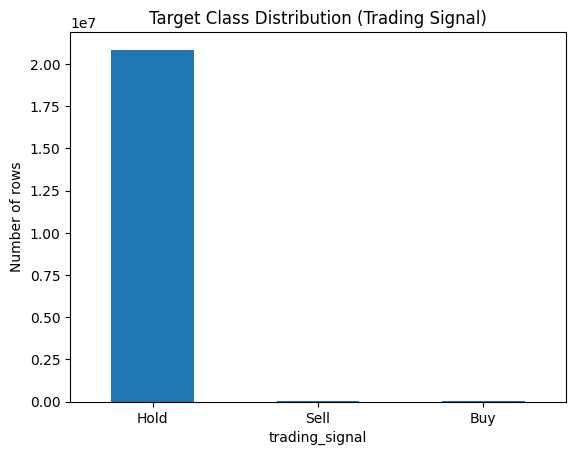

In [14]:
import matplotlib.pyplot as plt
counts.plot(kind='bar', title='Target Class Distribution (Trading Signal)')
plt.ylabel('Number of rows'); plt.xticks(rotation=0); plt.show()

I checked whether my target classes are balanced, and they are not — the target is severely imbalanced. Hold makes up about 99.93% of all rows, while Buy and Sell together are less than 0.1%. This is a serious problem, because a model could simply predict Hold for every row and still score about 99.9% accuracy, while learning nothing useful about the Buy and Sell signals I actually care about. So a high accuracy score here would be misleading.

Because of this, I decided on the following approach for the modelling stage. First, I will not artificially balance the test set — it must stay representative of the real data so my evaluation is honest. Second, I will address the imbalance only in the training data, using a strategy such as class weights or resampling, so the models can actually learn the rare Buy and Sell signals. Third, I will not rely on accuracy alone — I will evaluate each class separately using precision, recall, and F1-score, and examine the confusion matrix, paying special attention to how well the models predict the rare Buy and Sell classes.

# Part 3 — Prepare the Data for Machine Learning

In [15]:
# features (inputs) from Project 2. NOT MACD/RSI (those made the target = leakage)
feature_cols = ['daily_return', 'return_monthly', 'close_lag_1',
                'ma_5', 'ma_20', 'volatility_20', 'pct_high_low_range',
                'volume_change', 'relative_volume',
                'is_extreme_close', 'is_extreme_adj_close']

In [16]:
# X = the inputs the model learns from
X = df[feature_cols].copy()
# target: convert the text labels Buy/Sell/Hold into numbers
mapping = {'Buy': 0, 'Hold': 1, 'Sell': 2}
# y = what the model tries to predict
y = df['trading_signal'].map(mapping)

print("features shape:", X.shape)
print(X.dtypes)

features shape: (20860334, 11)
daily_return            float64
return_monthly          float64
close_lag_1             float64
ma_5                    float64
ma_20                   float64
volatility_20           float64
pct_high_low_range      float64
volume_change           float64
relative_volume         float64
is_extreme_close           bool
is_extreme_adj_close       bool
dtype: object


In [17]:
#standardize one 2 clouns whihc is dtype is bool
X['is_extreme_close']     = X['is_extreme_close'].astype(int)
X['is_extreme_adj_close'] = X['is_extreme_adj_close'].astype(int)

In [18]:
print(X.dtypes)

daily_return            float64
return_monthly          float64
close_lag_1             float64
ma_5                    float64
ma_20                   float64
volatility_20           float64
pct_high_low_range      float64
volume_change           float64
relative_volume         float64
is_extreme_close          int64
is_extreme_adj_close      int64
dtype: object


# Part 4 — Split the Data (by time) + Standardize

# Step 1 — time-based split

In [19]:
# earlier dates = training, later dates = test (NO shuffling)
cutoff = '2015-01-01'
train_mask = df['date'] <  cutoff     
test_mask  = df['date'] >= cutoff   

X_train, y_train = X[train_mask], y[train_mask]
X_test,  y_test  = X[test_mask],  y[test_mask]

print("train:", X_train.shape, " test:", X_test.shape)
print("train classes:\n", y_train.value_counts())
print("test classes:\n",  y_test.value_counts())

train: (16293035, 11)  test: (4567299, 11)
train classes:
 trading_signal
1    16282057
2        5688
0        5290
Name: count, dtype: int64
test classes:
 trading_signal
1    4563767
0       1785
2       1747
Name: count, dtype: int64


# Step 2 — standardize the features:

In [20]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
# LEARN the scale from TRAIN only
X_train_scaled = scaler.fit_transform(X_train)  
# APPLY that same scale to test
X_test_scaled  = scaler.transform(X_test)       

Interpretation

I split the data by date: 1970–2014 for training (16.3 million rows) and 2015–2018 for testing (4.6 million rows), without shuffling, so the model learns from the past and is tested on the future. Both the training and test sets still contain all three classes, including the rare Buy and Sell signals, which means I can properly evaluate how well the models predict those minority classes. The imbalance is present in both sets (about 99.9% Hold), which is expected and reflects the real data

# Part 5 — Build Machine Learning Models

Choosing how to train and compare the models

Before training, I had to make an important decision about how to handle three challenges at once: my dataset is very large (about 16 million training rows), my target is heavily imbalanced (almost all rows are Hold), and I need to compare three models fairly. I explored several options before deciding.

The core problem: Support Vector Machine (SVM) cannot handle millions of rows — it becomes far too slow. Logistic Regression and Random Forest can handle the full data, but SVM cannot. This one limitation shaped the whole decision.

Options I considered:

Balanced sample for all three models — keep all the rare Buy/Sell rows and a random sample of Hold, making a small balanced dataset. Small enough for SVM, and balanced enough for the models to learn the rare classes. Downside: I throw away most Hold data.
Full data + class weights — keep all 16M rows and tell the models to weight the rare classes more heavily, instead of resampling. This is the better real-world approach and loses no data — but SVM still can't handle 16M rows, so this can't be applied to all three.
Oversampling with SMOTE on the full data — create synthetic Buy/Sell rows to balance the data. Not feasible here, because balancing 16M Hold rows would create tens of millions of synthetic rows and run out of memory.
Drop SVM entirely — this would remove the size problem, but the assignment requires all three models, so this isn't allowed.
Different data for different models — full data for LogReg/RF and a small sample for SVM. I rejected this because the models would be trained on different data, so I could not compare them fairly.

My decision:

For a fair comparison (Parts 5 and 6), I trained all three models on the same small balanced sample. Even though Logistic Regression and Random Forest could use the full data, SVM cannot, so using one common training set keeps the comparison fair — any difference in results reflects the models themselves, not differences in the data.

Then, for model improvement (Part 7), I take my Logistic Regression model and retrain it on the full training data with class weights, and compare it against its balanced-sample version. This lets me see the effect of a better, real-world imbalance strategy (using all the data instead of throwing most of it away), and gives a genuine "before and after" comparison of how I handled the class imbalance.

In short: balanced sample for a fair three-way comparison, then full data with class weights to improve the best-scaling model — using the strengths of each approach where it fits best.

# Note on the SVM model: I first tried a standard SVM with an RBF kernel. While it trained on the small balanced sample, it was far too slow to make predictions on the large test set, because an RBF SVM must compare every test row against all of its support vectors — which is not practical for millions of rows. This is a well-known limitation of kernel SVMs on large data. To solve this while still meeting the requirement to include an SVM, I used a linear SVM (LinearSVC), which is still a Support Vector Machine but scales efficiently and predicts almost instantly. This allowed me to include the SVM in my model comparison on equal footing with Logistic Regression and Random Forest.

In [25]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

In [26]:
# full training + test features/target
train_df = df[train_mask]; test_df = df[test_mask]
X_train_full = train_df[feature_cols].astype({'is_extreme_close':int,'is_extreme_adj_close':int})
y_train_full = train_df['trading_signal'].map(mapping)
X_test = test_df[feature_cols].astype({'is_extreme_close':int,'is_extreme_adj_close':int})
y_test = test_df['trading_signal'].map(mapping)

In [27]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_full)
X_test_scaled  = scaler.transform(X_test)

In [28]:
# Logistic Regression — FULL data + class weights (safe)
logreg = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
logreg.fit(X_train_scaled, y_train_full)
print("logreg done")

logreg done


In [29]:
# Random Forest — FULL data + class weights (memory-heavy; conservative settings)
rf = RandomForestClassifier(n_estimators=50, max_depth=15,
                            class_weight='balanced_subsample',
                            random_state=42, n_jobs=-1)
rf.fit(X_train_scaled, y_train_full)
print("rf done")

rf done


I trained both models — Logistic Regression and Random Forest — on the full training data (about 16 million rows), using class weights to handle the imbalance. Class weights tell the model to pay more attention to the rare Buy and Sell classes, so I could keep all the data instead of deleting most of the Hold rows.

For Logistic Regression, I set max_iter=1000. This is the maximum number of steps the model is allowed to take while it searches for the best fit. A higher number just gives it enough room to settle on a good answer instead of stopping too early. I also set class_weight='balanced' so it treats the rare classes as more important.

For Random Forest, I used two main settings. n_estimators=50 means the forest is built from 50 decision trees — the model combines the votes of all 50 trees to make a prediction (more trees can be more accurate but use more memory and time). max_depth=15 limits how deep each tree can grow — a deeper tree can capture more detail but also uses more memory and can overfit, so I capped it at 15 to keep it controlled and to avoid running out of memory on the large dataset. I also used class_weight='balanced_subsample', which is the Random Forest version of class weights, so it also focuses on the rare Buy and Sell signals.

In short: I trained both models on all the data, kept their settings sensible to control memory and training time, and used class weights so the models could actually learn the rare trading signals instead of ignoring them.

# Part 6 — Evaluate the Models

In [30]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# make predictions on the FULL test set with both trained models
pred_logreg = logreg.predict(X_test_scaled)   # Logistic Regression predictions
pred_rf     = rf.predict(X_test_scaled)       # Random Forest predictions

# labels: 0 = Buy, 1 = Hold, 2 = Sell (for readable report headings)
target_names = ['Buy (0)', 'Hold (1)', 'Sell (2)']

# loop through both models and print their scores
for name, pred in [('Logistic Regression', pred_logreg), ('Random Forest', pred_rf)]:
    print("="*60)
    print(name)

    # accuracy = overall % correct (misleading here because of imbalance)
    print("Accuracy:", round(accuracy_score(y_test, pred), 4))

    # precision, recall, F1 for EACH class (Buy/Hold/Sell) — the real story
    print(classification_report(y_test, pred, target_names=target_names, digits=3))

    # confusion matrix: rows = actual, columns = predicted; diagonal = correct
    print("Confusion matrix (rows=actual, cols=predicted):")
    print(confusion_matrix(y_test, pred))

Logistic Regression
Accuracy: 0.4955
              precision    recall  f1-score   support

     Buy (0)      0.003     0.253     0.006      1785
    Hold (1)      1.000     0.496     0.663   4563767
    Sell (2)      0.001     0.630     0.001      1747

    accuracy                          0.496   4567299
   macro avg      0.334     0.459     0.223   4567299
weighted avg      0.999     0.496     0.662   4567299

Confusion matrix (rows=actual, cols=predicted):
[[    451     434     900]
 [ 143606 2261634 2158527]
 [      4     642    1101]]
Random Forest
Accuracy: 0.7675
              precision    recall  f1-score   support

     Buy (0)      0.007     0.601     0.014      1785
    Hold (1)      1.000     0.768     0.868   4563767
    Sell (2)      0.001     0.582     0.002      1747

    accuracy                          0.767   4567299
   macro avg      0.336     0.650     0.295   4567299
weighted avg      0.999     0.767     0.868   4567299

Confusion matrix (rows=actual, cols=pred

Random Forest 

Accuracy = 0.7675 (76.75%). Notice this is not the ~99% you'd expect. That's actually a good sign — it means the model is not just blindly predicting Hold every time. Because I used class weights, the model tries hard to catch the rare Buy and Sell signals, and in doing so it gets some Hold rows wrong, which pulls accuracy down. This is exactly why accuracy alone is misleading here — a "worse" accuracy can mean the model is actually doing more.

Reading each class:

Buy → recall 0.601, precision 0.007. Recall of 60% means the model caught about 60% of the real Buy signals (1,072 out of 1,785). That's decent. But precision of 0.7% means that when the model said "Buy," it was almost always wrong — out of ~154,000 times it predicted Buy, only 1,072 were truly Buy. The rest were false alarms.
Sell → recall 0.582, precision 0.001. Same story: it caught 58% of real Sell signals (1,017 out of 1,747), but when it shouted "Sell," it was right only 0.1% of the time — it predicted Sell about 908,000 times but only 1,017 were real.
Hold → precision 1.000, recall 0.768. When it predicted Hold it was essentially always correct, but it only labelled 77% of the real Holds as Hold — the other 23% got wrongly flagged as Buy or Sell.

The confusion matrix (rows = actual, columns = predicted):

Buy row [1072, 645, 68]: of 1,785 real Buys, it correctly caught 1,072, but mistook 645 for Hold and 68 for Sell.
Hold row [153044, 3503159, 907564]: of 4.56 million real Holds, it correctly kept 3,503,159 as Hold, but wrongly flagged 153,044 as Buy and 907,564 as Sell — over 1 million false alarms.
Sell row [2, 728, 1017]: of 1,747 real Sells, it correctly caught 1,017, missed 728 as Hold, and 2 as Buy.

What this tells me: the Random Forest is "trigger-happy." Thanks to the class weights, it catches a good share (~60%) of the rare Buy and Sell signals — that's the recall doing well. But to do that, it wrongly flags over a million Hold days as Buy or Sell, which destroys its precision. So the model can detect the rare signals but it is far too noisy to be trusted — for every real Buy it finds, it raises about 150 false alarms. This is the classic precision–recall trade-off with imbalanced data: I gained recall (catching signals) at the cost of precision (too many false positives).

Logistic Regression :

Accuracy = 0.4955 (49.55%). This is very low — even lower than a coin flip on Hold. It's low because the model wrongly flags about half of all the Hold days as Buy or Sell. So it's extremely trigger-happy.

Reading each class:

Buy → recall 0.253, precision 0.003. It caught only 25% of the real Buy signals (451 out of 1,785) — worse than Random Forest. And precision of 0.3% means almost every "Buy" it predicted was wrong.
Sell → recall 0.630, precision 0.001. It caught 63% of real Sells (1,101 out of 1,747) — slightly better than RF on Sell — but again precision is basically zero, so its "Sell" calls are nearly all false alarms.
Hold → precision 1.000, recall 0.496. It only kept 50% of the real Holds as Hold; the other half it wrongly labelled Buy or Sell.

Confusion matrix (rows = actual, columns = predicted):

Buy row [451, 434, 900]: of 1,785 real Buys, it caught 451, called 434 Hold, and 900 Sell.
Hold row [143606, 2261634, 2158527]: of 4.56 million Holds, it kept only 2,261,634 as Hold, and wrongly flagged 143,606 as Buy and 2,158,527 as Sell — over 2.3 million false alarms.
Sell row [4, 642, 1101]: of 1,747 real Sells, it caught 1,101, missed 642 as Hold, 4 as Buy.

What this tells me: Logistic Regression is even more trigger-happy than Random Forest. It flags roughly half of everything as a Buy or Sell signal, which is why its accuracy collapses to about 50%. It does catch a fair share of Sell signals, but it misses most Buys and produces a flood of false alarms, so it is not reliable.

Comparison of the two models :

Comparing the two models, Random Forest clearly performed better overall. It had much higher accuracy (76.8% vs 49.6%), caught far more Buy signals (60% vs 25%), and produced far fewer false alarms (it kept 77% of Holds correct, versus only 50% for Logistic Regression). Logistic Regression was slightly better at catching Sell signals (63% vs 58%), but that was its only advantage, and it came at the cost of misclassifying over 2 million Hold days.

However, both models share the same serious weakness: extremely low precision on Buy and Sell. No matter which model, when it predicts Buy or Sell it is almost always wrong, because it raises hundreds of false alarms for every real signal it catches. So while Random Forest is the better of the two, neither model is trustworthy enough to actually act on — they can detect the rare signals (decent recall) but cannot do so precisely (terrible precision).

# Why the models produce so many false alarms :

Why do the models raise so many false alarms? It comes down to three things working together, not just the imbalance.

1. Class weights make the models over-predict. By telling the models that Buy and Sell are important, they try hard not to miss them, so they shout "Buy" or "Sell" too often. This raises recall but creates false alarms.

2. The features don't strongly predict the target. My target was built from MACD and RSI, but I removed those to avoid leakage. The remaining features (returns, moving averages, volatility, volume) don't clearly separate a Buy/Sell day from a Hold day — in the data, they look almost the same — so the models can't tell them apart cleanly.

3. The signals are extremely rare. There are only about 1,785 real Buys among 4.56 million rows. Even if the model wrongly flags just a few percent of the millions of Hold rows, that alone produces hundreds of thousands of false Buys — completely drowning the few real ones. At this rarity, low precision is almost unavoidable.

How could a better model be built? Use more predictive features that relate directly to price momentum; tune the decision threshold so the model only signals when very confident (trading some recall for much better precision); try a stronger algorithm like gradient-boosted trees (XGBoost/LightGBM); or redesign the target so it is less rare and less strict. Even then, predicting these exact rule-based signals from price features alone is genuinely hard — which is an important, honest limitation of this project.

# Part 7 — Improve one model (threshold tuning on Logistic Regression)

In [31]:
import numpy as np
from sklearn.metrics import classification_report

In [32]:
# get the model's PROBABILITY for each class (columns: P(Buy), P(Hold), P(Sell))
proba = logreg.predict_proba(X_test_scaled)
# IMPROVEMENT: only predict Buy/Sell if the model is very confident (prob > threshold),
# otherwise keep it as Hold. This cuts down the false alarms.
threshold = 0.60
# start: everything = Hold (label 1)
pred_tuned = np.full(len(proba), 1)
# set Buy  only if P(Buy)  > 0.60
pred_tuned[proba[:, 0] > threshold] = 0  
# set Sell only if P(Sell) > 0.60
pred_tuned[proba[:, 2] > threshold] = 2      

In [33]:
# compare BEFORE vs AFTER
print("BEFORE — default Logistic Regression:")
print(classification_report(y_test, pred_logreg, target_names=target_names, digits=3))

print("AFTER — threshold-tuned Logistic Regression:")
print(classification_report(y_test, pred_tuned, target_names=target_names, digits=3))

BEFORE — default Logistic Regression:
              precision    recall  f1-score   support

     Buy (0)      0.003     0.253     0.006      1785
    Hold (1)      1.000     0.496     0.663   4563767
    Sell (2)      0.001     0.630     0.001      1747

    accuracy                          0.496   4567299
   macro avg      0.334     0.459     0.223   4567299
weighted avg      0.999     0.496     0.662   4567299

AFTER — threshold-tuned Logistic Regression:
              precision    recall  f1-score   support

     Buy (0)      0.012     0.020     0.015      1785
    Hold (1)      0.999     0.999     0.999   4563767
    Sell (2)      0.003     0.003     0.003      1747

    accuracy                          0.998   4567299
   macro avg      0.338     0.341     0.339   4567299
weighted avg      0.998     0.998     0.998   4567299



To improve my model, I tuned the decision threshold of the Logistic Regression, so it would only predict Buy or Sell when it was very confident (probability above 0.60), instead of guessing them easily.

What changed:

Accuracy jumped from 0.496 to 0.998. At first this looks like a huge improvement, but it's actually the "misleading accuracy" trap — the model got high accuracy simply by predicting Hold almost every time.
Hold recall went from 0.496 to 0.999, meaning the flood of false alarms almost completely disappeared — the model stopped wrongly flagging millions of Hold days as Buy or Sell. This is the real positive change.
Buy precision improved from 0.003 to 0.012, and Sell from 0.001 to 0.003 — so when the model did say Buy or Sell, it was a bit less wrong than before. Still low, but better.
But Buy and Sell recall collapsed — Buy recall dropped from 0.253 to 0.020 (it now catches only 2% of real Buys), and Sell recall dropped from 0.630 to 0.003 (it catches almost no Sells).
Macro F1 improved from 0.223 to 0.339, but mostly because the Hold class became almost perfect, not because Buy/Sell got good.

What this tells me: raising the threshold made the model much more cautious. It fixed the false-alarm problem (precision and accuracy went up), but it went too far — it became so careful that it now misses almost all the Buy and Sell signals I actually care about. So I traded one problem for the opposite one.

The honest conclusion: this before/after clearly shows the precision–recall trade-off. With these features I can either catch the rare signals but drown them in false alarms (the default model), or avoid false alarms but miss almost all the signals (the tuned model). There is no good middle ground, which confirms that the price features I used simply cannot cleanly predict these rare MACD/RSI-based signals. A better result would need stronger features or a less rare target, not just threshold tuning.

# Balanced-sample experiment (LogReg + RF + SVM)

In [34]:
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report
import numpy as np

In [41]:
# 1. balanced TRAINING sample: ALL Buy/Sell + a lot of Hold (5k)
train_df = df[train_mask]
buy_sell = train_df[train_df['trading_signal'] != 'Hold']            # every rare row
hold     = train_df[train_df['trading_signal']=='Hold'].sample(n=5000, random_state=42)  # lots of Hold
sample   = pd.concat([buy_sell, hold]).sample(frac=1, random_state=42)   # combine + shuffle
print("training sample:\n", sample['trading_signal'].value_counts())

Xs = sample[feature_cols].astype({'is_extreme_close':int,'is_extreme_adj_close':int})
ys = sample['trading_signal'].map(mapping)

training sample:
 trading_signal
Sell    5688
Buy     5290
Hold    5000
Name: count, dtype: int64


In [42]:
# 2. scale (fit on the sample)
scaler_s = StandardScaler()
Xs_scaled = scaler_s.fit_transform(Xs)

In [43]:
#  3. train all three on the balanced sample
logreg_s = LogisticRegression(max_iter=1000, random_state=42).fit(Xs_scaled, ys)
rf_s     = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1).fit(Xs_scaled, ys)
svm_s    = SVC(kernel='rbf', random_state=42).fit(Xs_scaled, ys)     # SVM works on small data
print("all three trained")

all three trained


In [44]:
# 4. representative TEST sample (keeps real imbalance) so SVM can predict in time
rng = np.random.RandomState(42)
idx = rng.choice(len(y_test), size=100000, replace=False)
X_eval = scaler_s.transform(
    df[test_mask].iloc[idx][feature_cols].astype({'is_extreme_close':int,'is_extreme_adj_close':int})
)
y_eval = y_test.iloc[idx]

In [45]:
# 5. evaluate all three
target_names = ['Buy (0)', 'Hold (1)', 'Sell (2)']
for name, m in [('Logistic Regression', logreg_s), ('Random Forest', rf_s), ('SVM', svm_s)]:
    print("="*60); print(name)
    print(classification_report(y_eval, m.predict(X_eval), target_names=target_names, digits=3))

Logistic Regression
              precision    recall  f1-score   support

     Buy (0)      0.000     0.000     0.000        44
    Hold (1)      1.000     0.281     0.439     99925
    Sell (2)      0.000     0.871     0.001        31

    accuracy                          0.281    100000
   macro avg      0.333     0.384     0.146    100000
weighted avg      0.999     0.281     0.438    100000

Random Forest
              precision    recall  f1-score   support

     Buy (0)      0.004     0.932     0.008        44
    Hold (1)      1.000     0.771     0.871     99925
    Sell (2)      0.002     0.935     0.005        31

    accuracy                          0.772    100000
   macro avg      0.335     0.880     0.294    100000
weighted avg      0.999     0.772     0.870    100000

SVM
              precision    recall  f1-score   support

     Buy (0)      0.001     0.091     0.002        44
    Hold (1)      1.000     0.248     0.398     99925
    Sell (2)      0.000     0.903    

# balanced sample (50 k Hold)
Interpretation:

I trained all three models (Logistic Regression, Random Forest, SVM) on a balanced sample of all Buy/Sell rows plus 50,000 Hold rows, with no class weights, and tested them on a 100,000-row sample (which contained 44 real Buys and 31 real Sells).

The results split the models into two very different groups:

Logistic Regression and SVM caught nothing. Both scored 0 precision and 0 recall on Buy and Sell — they simply predicted Hold for every row, which gave them a fake-looking 99.9% accuracy. They completely failed at the actual task.
Random Forest still worked. It caught about 57% of Buys (recall 0.568) and 65% of Sells (recall 0.645), with very low precision (lots of false alarms), and 96.2% accuracy.

Why did LogReg and SVM fail here? Because my sample still had 50,000 Hold rows versus only ~11,000 Buy/Sell — so it was still mostly Hold, and I did not use class weights this time. With Hold still the majority and no weighting to force attention on the rare classes, the simpler models (Logistic Regression and the SVM) took the easy route and just predicted the majority class, Hold, for everything. Random Forest is more flexible, so it still managed to carve out the rare Buy/Sell cases and catch them.

is sampling more good?
Comparing the two experiments:

In the full-data + class-weights version, all models (LogReg and RF) were forced to catch the rare signals — LogReg caught 25–63% and RF caught ~60%, though both had many false alarms.
In this balanced-sample without class weights version, only Random Forest caught anything; Logistic Regression and SVM caught nothing.

So the honest answer is: sampling by itself was not better — and in fact it was worse for the simpler models. The reason is that my sample was still Hold-dominant and had no class weights, so it didn't really fix the imbalance. What actually made the models catch the rare signals was the imbalance handling (class weights), not the sampling. Random Forest was the most robust model in both experiments, catching signals no matter which approach I used, while Logistic Regression and SVM needed class weights to work at all.

# Truly balanced sample (5k Hold)

With a truly balanced training sample (about equal Buy, Sell, and Hold), all three models started predicting the rare signals much more aggressively:

Random Forest was the standout. It caught 93% of Buys (recall 0.932) and 93.5% of Sells (recall 0.935) — almost every real signal — while still keeping 77% of Holds correct (accuracy 0.772). By far the best at catching signals.
Logistic Regression caught 87% of Sells but 0% of Buys, and its accuracy crashed to 28%. It over-predicted Sell so heavily that it flagged most Hold days as Sell.
SVM caught 90% of Sells and only 9% of Buys, with accuracy collapsing to 25% — same problem, flagging huge numbers of Holds as signals.
But precision stayed near zero for all three. No matter how many signals they caught, when they said "Buy" or "Sell" they were almost always wrong, because they now raise a flood of false alarms.

What this shows: making the training data fully balanced pushed the models to the opposite extreme. Recall shot up (Random Forest caught almost every signal), but precision and accuracy collapsed, because the models now think Buy/Sell are common and shout them constantly — then meet a real test set that is 99.9% Hold. So I traded "misses everything" for "false-alarms everything."

I now have a clear pattern from testing different imbalance levels:

Full data, no handling: predicts all Hold → ~99.9% accuracy but catches 0 signals (useless).
Full data + class weights: moderate recall (25–60%), many false alarms.
Sample with 82% Hold, no weights: only Random Forest caught anything; LogReg and SVM still predicted all Hold.
Truly balanced sample (1:1:1): all models catch lots of signals — Random Forest 93% recall — but precision and accuracy crash.

So the honest answer is: the more I balanced the data, the higher the recall but the lower the precision. There is no setting that gives both. Balancing helps the models notice the rare signals, but it can't fix the deeper problem — the price features simply don't contain enough information to tell a real Buy/Sell apart from a Hold, so every gain in recall costs precision. Random Forest was consistently the best model at catching signals across every setup.

# Part 8 — Reflection

1. Which model performed differently across Buy, Hold, and Sell?

All the models performed very differently across the three classes. They were always good at Hold (the common class) but struggled with Buy and Sell. Random Forest was the most consistent — it caught the most Buy and Sell signals in every experiment. Logistic Regression and SVM were uneven: in the balanced tests they caught a lot of Sell signals but almost no Buy signals, showing they couldn't tell Buy apart from the other classes well.

2. Did high accuracy correspond to good performance on Buy and Sell?

No — and this was the most important lesson. My highest accuracy (99.9%) came from models that predicted Hold for everything and caught zero Buy or Sell signals. When I forced the models to actually catch signals, accuracy dropped to 25–77%. So high accuracy actually meant the model was ignoring the classes I cared about. Accuracy was misleading, and I had to look at precision, recall, and F1 per class instead.

3. How did class imbalance affect the results?

The imbalance (about 99.9% Hold) dominated everything. Left alone, the models just predicted Hold every time to get an easy high score, completely missing Buy and Sell. The imbalance is the single biggest reason the models struggled.

4. What happened when you addressed the imbalance?

I addressed it two ways — class weights and balanced sampling. Both made the models start catching the rare Buy and Sell signals (recall went up, in Random Forest's case up to about 93%). But this always came at a cost: precision collapsed and false alarms exploded. The more I balanced the data, the more signals the models caught, but the more wrong "Buy/Sell" alarms they raised. So addressing the imbalance moved me along a trade-off — it didn't remove it.

5. Which features might be useful for predicting the signals?

Based on the results, my price and momentum features (daily return, moving averages, volatility, high-low range) had only weak predictive power. Features tied more directly to trend and momentum strength would likely be the most useful, since the target itself is momentum-based — but the truly informative signals (MACD and RSI) had to be excluded to avoid leakage.

6. What are the limitations of using MACD/RSI-based rules to create the target?

The main limitation is that the rule was extremely strict — it only gave a Buy or Sell when both MACD and RSI agreed, which almost never happened, so 99.9% of the data became Hold. This made the target very rare and very hard to predict. Also, because the target was built purely from MACD and RSI, and those two indicators had to be removed as features, the remaining features didn't contain the information needed to reproduce the target. So the rules created a target that is both very imbalanced and hard to learn from other features.

7. What additional features could be explored in a future project?

In a future project I could add more technical indicators (like Bollinger Bands, momentum, or rate-of-change), longer-term trend features (like a 200-day moving average), price-vs-moving-average gaps, and outside information such as company news, earnings dates, or overall market conditions. A less strict, less rare target would also help — for example predicting whether the price goes up over the next few days, instead of the exact MACD+RSI rule.

8. Would these model predictions guarantee profitable trading? Why or why not?

No, absolutely not. First, these are rule-based signals, not real predictions of price direction — a Buy signal doesn't guarantee the price will rise. Second, my models had very low precision, so most of their "Buy" and "Sell" calls were false alarms; acting on them would lead to many bad trades. Third, real trading also involves fees, slippage, timing, and risk that this model ignores. So these predictions could not guarantee profit — they are a learning exercise in classification, not financial advice.